The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


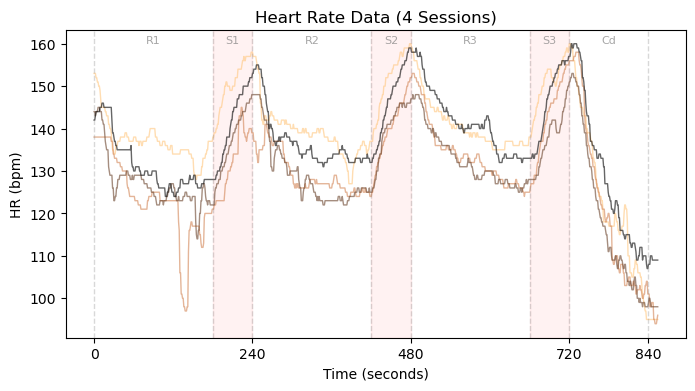

In [2]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from workout import *
from bspline_model import TreadmillAnalytic, TreadmillReport




# Your current specific workout: 3 reps of (3m low, 1m high) + 2m cooldown
standard_3x4 = WorkoutConfig(phases=[
    WorkoutPhase(f"R1", 180, 'low'), WorkoutPhase(f"S1", 60, 'high'),
    WorkoutPhase(f"R2", 180, 'low'), WorkoutPhase(f"S2", 60, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 60, 'high'),
    WorkoutPhase("Cd", 120, 'cooldown')
])

file_paths = list(sorted(Path("polar_data").glob("*.CSV")))
report = TreadmillReport(standard_3x4, file_paths, False)
report.plot_raw_data()

In [16]:
import arviz as az
session = report.sessions[0]

from bspline_model import MedianHdiSample
from bspline_model import MedianHdi

print(
    session.post_mu.shape, 
    az.hdi(session.post_mu, hdi_prob=0.89).shape,
    MedianHdiSample.from_samples(session.post_mu, session.post_mu.shape[0]).hdi_lower.shape
)
# MedianHdiSample.from_samples(session.post_mu, session.post_mu.shape[0]).hdi

(1000, 855) (855, 2) (855,)


/var/folders/kq/2zfcdcr577b47rsq8qxqmwjw0000gp/T/ipykernel_84809/2588827261.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  az.hdi(session.post_mu, hdi_prob=0.89).shape,
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions


# B-Splines

<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
<string>:5: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence w

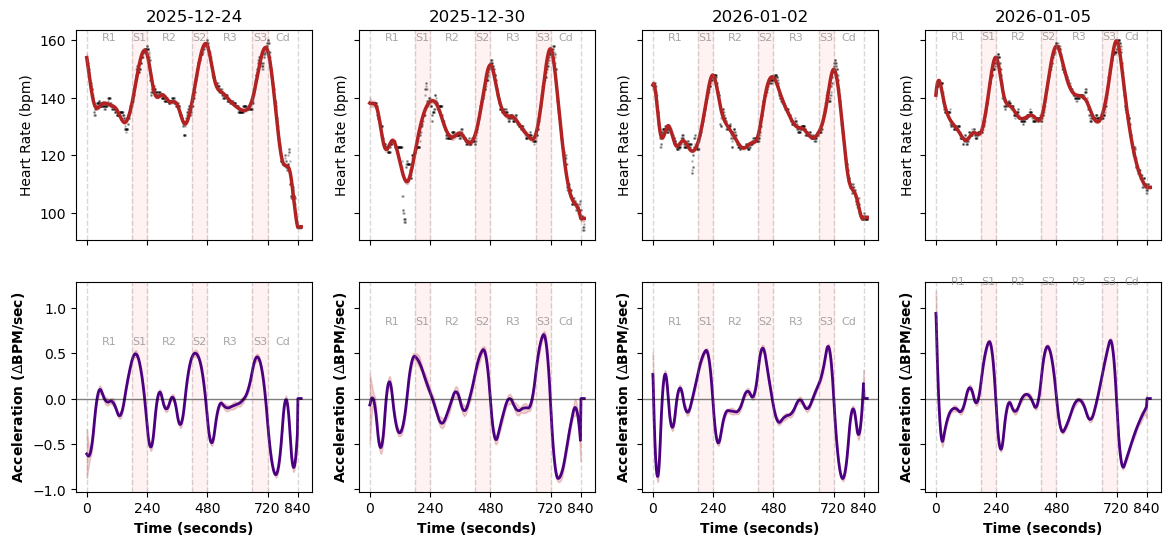

In [17]:
fig, axes = plt.subplots(ncols=len(report.sessions), nrows=2, figsize=(14, 6), sharex=True, sharey='row')
report.plot_fit_accel(fig, axes)

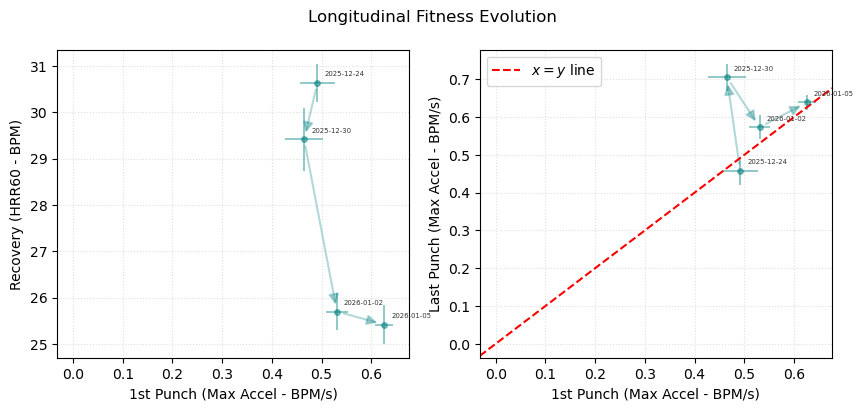

In [22]:
report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0, 0), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


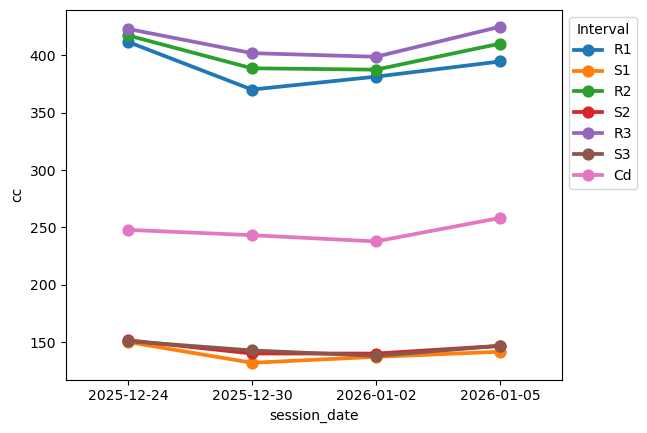

In [23]:
report.plot_cardiac_cost()